# Income > $50K: Logistic Regression vs. a Small Neural Network

Break Through Tech AI capstone. 1994 US Census (Adult) data; binary classification on
whether an individual earns more than $50,000.

The interesting result here is not which model wins. Both land in roughly the same place on
aggregate metrics, and **both miss high-earning women at a much higher rate than
high-earning men.** The neural network's smaller recall gap does not come from finding more
high-earning women — a paired test says its apparent gain there is indistinguishable from
noise — but from missing 48 more high-earning men. Aggregate accuracy can't see any of it,
because high-earning women are 3.7% of the test set.

| | Logistic Regression | Neural Network |
|---|---|---|
| Accuracy | 0.8186 | 0.8299 |
| F1 | 0.6941 | 0.7029 |
| Recall, female | 0.7507 | 0.7619 |
| Recall, non-female | 0.8732 | 0.8491 |
| **Recall gap** | **12.25 pts** | **8.72 pts** |
| Precision, female | 0.5969 | 0.6071 |
| Precision, non-female | 0.5824 | 0.6063 |

Note the last two rows: precision is near-identical across groups in both models while recall
differs by 9–12 points. Which fairness criterion you check determines whether you see a
problem at all.

Full write-up in [Findings](#7-findings), caveats in
[Limitations](#8-limitations-and-known-issues).

---

### A note on the data

These outputs come from the **public UCI Adult file**, so they reproduce from a clean clone.

An earlier version of this notebook ran against the course-provided `censusData.csv`, a
modified copy with injected missingness in `age` and `hours-per-week` and a `capital-gain`
capped at 14,084 instead of the 99,999 top-code. That file isn't redistributed here.
Section 7.5 reports both runs side by side — the finding survives the data swap, an
encoding fix, and a TensorFlow major version, which is more robustness than a single run
would have shown.

## 1. Setup

In [1]:
import os
import time
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binomtest

# [CHANGE 1] Pipeline / ColumnTransformer / SimpleImputer / OneHotEncoder were
# used below but never imported.
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import keras

SEED = 316
keras.utils.set_random_seed(SEED)   # seeds python random, numpy, and the backend

## 2. Load the data

`load_census()` prefers a local `data/censusData.csv` (the course file, gitignored) and
otherwise downloads the public UCI Adult data and renames it into the same schema:
`sex` → `sex_selfID` with `Male` → `Non-Female`, `income` → `income_binary`,
`Amer-Indian-Eskimo` → `Amer-Indian-Inuit`, and `?` → `NaN`.

The committed outputs are from the public path.

In [2]:
COURSE_CSV = Path("data/censusData.csv")   # not redistributed; see note above
UCI_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
UCI_CACHE = Path("data/adult.data")

UCI_COLUMNS = [
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
    "hours-per-week", "native-country", "income",
]


def load_census():
    if COURSE_CSV.exists():
        return pd.read_csv(COURSE_CSV)

    UCI_CACHE.parent.mkdir(parents=True, exist_ok=True)
    if not UCI_CACHE.exists():
        urllib.request.urlretrieve(UCI_URL, UCI_CACHE)

    df = pd.read_csv(
        UCI_CACHE, header=None, names=UCI_COLUMNS,
        skipinitialspace=True, na_values=["?"],
    )
    # match the schema the notebook was written against
    df = df.rename(columns={"sex": "sex_selfID", "income": "income_binary"})
    df["sex_selfID"] = df["sex_selfID"].replace({"Male": "Non-Female"})
    df["race"] = df["race"].replace({"Amer-Indian-Eskimo": "Amer-Indian-Inuit"})
    df["age"] = df["age"].astype(float)
    df["hours-per-week"] = df["hours-per-week"].astype(float)
    return df


df = load_census()
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## 3. Exploratory analysis

### 3.1 Class balance

Roughly 76/24. Moderate imbalance — not severe, but enough that accuracy is misleading,
since predicting "under 50K" for everyone already scores ~76%. Everything below leans on
F1 and on subgroup recall rather than accuracy.

In [3]:
pcts = df['income_binary'].value_counts(normalize=True) * 100
pcts

income_binary
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64

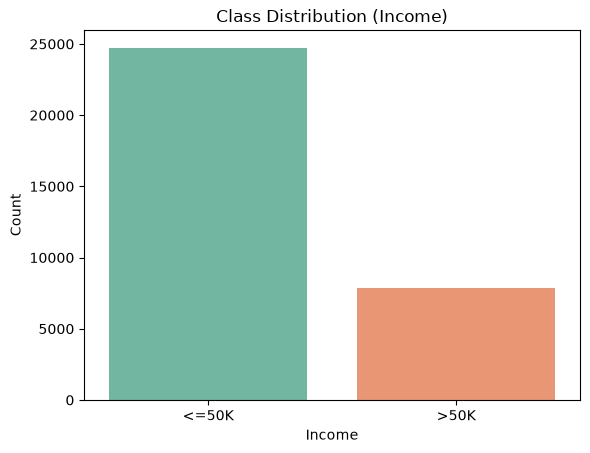

In [4]:
sns.countplot(data=df, x="income_binary", hue="income_binary", palette="Set2", legend=False)
plt.title("Class Distribution (Income)")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

### 3.2 Numeric features

`capital-gain` and `capital-loss` are zero for most rows with long right tails;
`hours-per-week` spikes hard at 40 with tails both directions; `age` is mildly right-skewed.
All of that argues for median imputation over mean where imputation is needed, and for
scaling before any distance- or gradient-based model.

**`capital-gain` carries a 99,999 sentinel** — a top-code, not a dollar amount. It's 0.5% of
rows but it drags the mean to 1,078 against a median of 0, and standardizing leaves it as an
extreme outlier. It also turns out to be the largest positive coefficient in the fitted model
(section 5.1), so this is not cosmetic. Left unclipped here; noted in limitations.

In [5]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


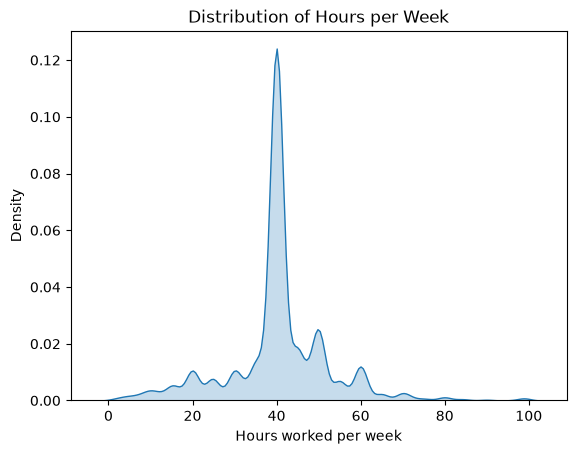

In [6]:
sns.kdeplot(data=df, x="hours-per-week", fill=True)
plt.title("Distribution of Hours per Week")
plt.xlabel("Hours worked per week")
plt.show()

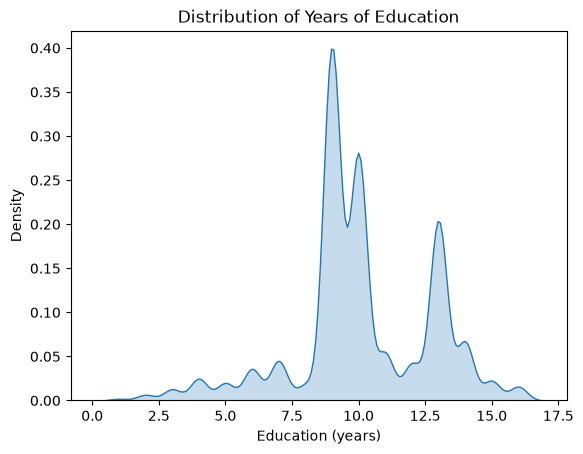

In [7]:
sns.kdeplot(data=df, x="education-num", fill=True)
plt.title("Distribution of Years of Education")
plt.xlabel("Education (years)")
plt.show()

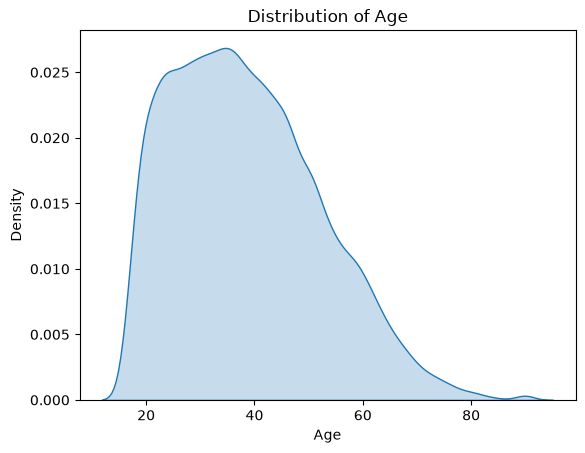

In [7]:
sns.kdeplot(data=df, x="age", fill=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.show()

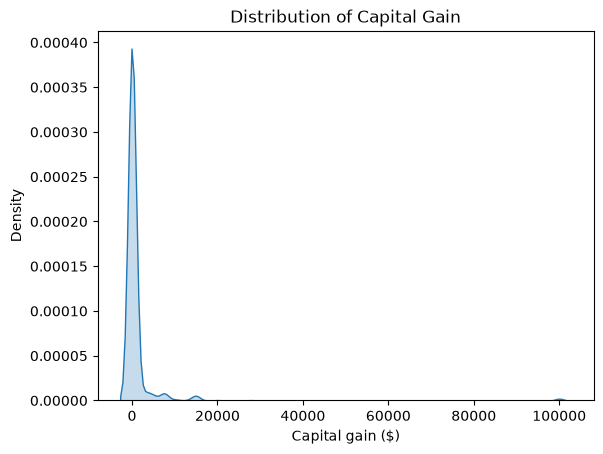

In [9]:
sns.kdeplot(data=df, x="capital-gain", fill=True)
plt.title("Distribution of Capital Gain")
plt.xlabel("Capital gain ($)")
plt.show()

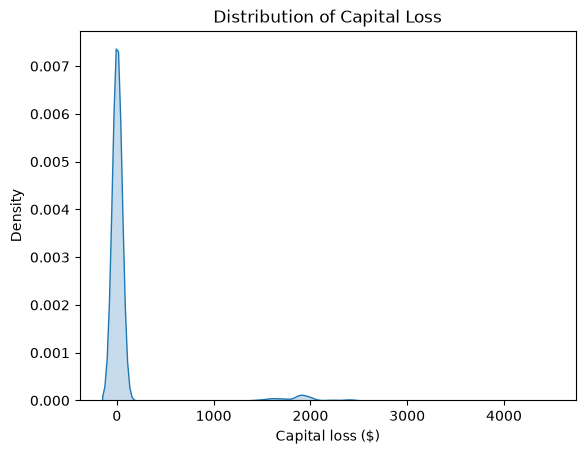

In [8]:
sns.kdeplot(data=df, x="capital-loss", fill=True)
plt.title("Distribution of Capital Loss")
plt.xlabel("Capital loss ($)")
plt.show()

### 3.3 Categorical features

In [11]:
print(df['income_binary'].unique().tolist())
print(df['sex_selfID'].unique().tolist())
print(df['race'].unique().tolist())
print(df['native-country'].unique().tolist())

['<=50K', '>50K']
['Non-Female', 'Female']
['White', 'Black', 'Asian-Pac-Islander', 'Amer-Indian-Inuit', 'Other']
['United-States', 'Cuba', 'Jamaica', 'India', nan, 'Mexico', 'South', 'Puerto-Rico', 'Honduras', 'England', 'Canada', 'Germany', 'Iran', 'Philippines', 'Italy', 'Poland', 'Columbia', 'Cambodia', 'Thailand', 'Ecuador', 'Laos', 'Taiwan', 'Haiti', 'Portugal', 'Dominican-Republic', 'El-Salvador', 'France', 'Guatemala', 'China', 'Japan', 'Yugoslavia', 'Peru', 'Outlying-US(Guam-USVI-etc)', 'Scotland', 'Trinadad&Tobago', 'Greece', 'Nicaragua', 'Vietnam', 'Hong', 'Ireland', 'Hungary', 'Holand-Netherlands']


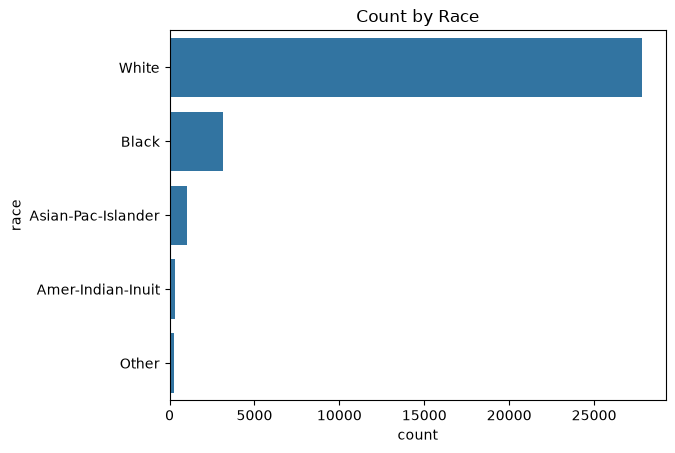

In [12]:
sns.countplot(y='race', data=df)
plt.title("Count by Race")
plt.show()

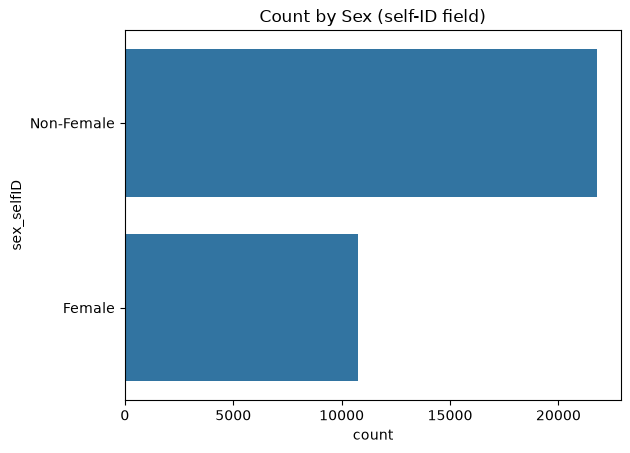

In [13]:
sns.countplot(y='sex_selfID', data=df)
plt.title("Count by Sex (self-ID field)")
plt.show()

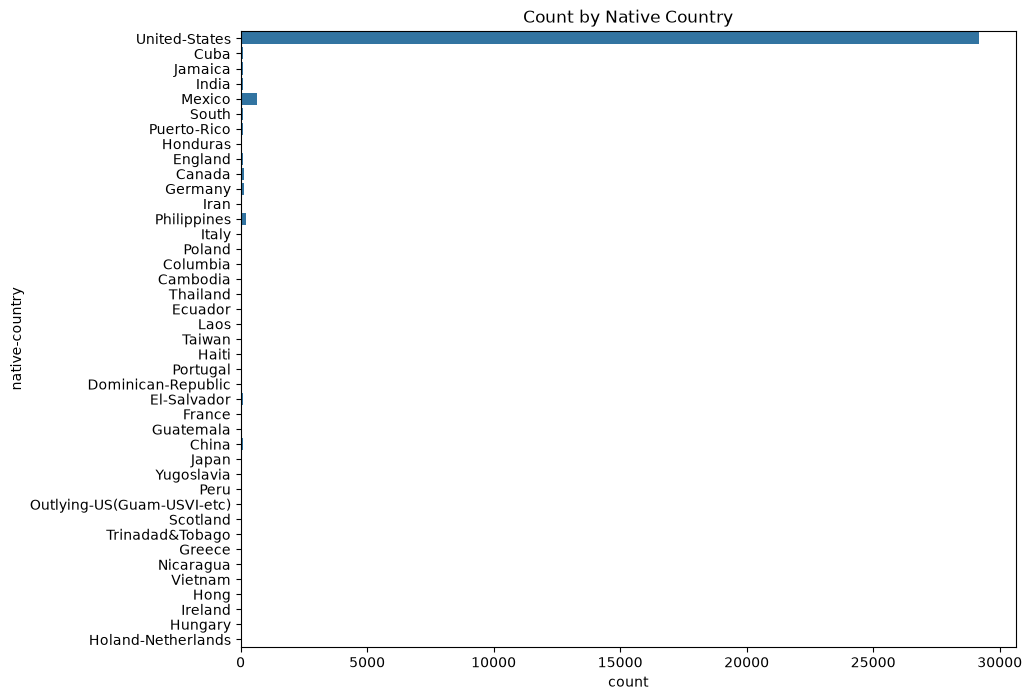

In [14]:
plt.figure(figsize=(10, 8))
sns.countplot(y='native-country', data=df)
plt.title("Count by Native Country")
plt.show()

In [15]:
print(df['native-country'].value_counts(normalize=True) * 100)

native-country
United-States                 91.218963
Mexico                         2.010757
Philippines                    0.619176
Germany                        0.428420
Canada                         0.378385
Puerto-Rico                    0.356495
El-Salvador                    0.331478
India                          0.312715
Cuba                           0.297079
England                        0.281443
Jamaica                        0.253299
South                          0.250172
China                          0.234536
Italy                          0.228282
Dominican-Republic             0.218900
Vietnam                        0.209519
Guatemala                      0.200138
Japan                          0.193883
Poland                         0.187629
Columbia                       0.184502
Taiwan                         0.159485
Haiti                          0.137595
Iran                           0.134467
Portugal                       0.115705
Nicaragua                

### 3.4 Sex and the label

This is the check that drives the rest of the notebook. The sample is ~67/33
non-female/female, against roughly 50/50 in the real 1994 population, so it isn't
representative on sex to begin with. The question is whether the label rate differs by
sex, and by how much.

In [4]:
df['is_female'] = df['sex_selfID'].map({'Female': 1, 'Non-Female': 0})
df['makes_over_50k'] = df['income_binary'].map({'>50K': 1, '<=50K': 0})
df['is_US_native'] = (df['native-country'] == 'United-States').astype(int)

print("CORRELATIONS", end="\n\n")
print(f"Is female / makes over 50K: {df['is_female'].corr(df['makes_over_50k'])}")
print(f"Is non-female / makes over 50K: {-df['is_female'].corr(df['makes_over_50k'])}")
print("\n")
print(f"Is non-US-native / makes over 50K: {df['is_US_native'].corr(df['makes_over_50k'])}")
print(f"Is US-native / makes over 50K: {-df['is_US_native'].corr(df['makes_over_50k'])}")

CORRELATIONS

Is female / makes over 50K: -0.21598015058403677
Is non-female / makes over 50K: 0.21598015058403677


Is non-US-native / makes over 50K: 0.03447035976703845
Is US-native / makes over 50K: -0.03447035976703845


In [5]:
# positive rate within each sex
(pd.crosstab(df['is_female'], df['makes_over_50k'], normalize='index') * 100).round(2)

makes_over_50k,0,1
is_female,,
0,69.43,30.57
1,89.05,10.95


In [6]:
(pd.crosstab(df['is_female'], df['is_US_native'], normalize='index') * 100).round(2)

is_US_native,0,1
is_female,,
0,10.56,89.44
1,10.11,89.89


The gap is large: **30.6% of non-females are over 50K versus 10.9% of females**, and the
overall correlation between `is_female` and the label is −0.22. So *within* the female
subgroup the label is roughly 89/11, considerably worse than the 76/24 global split.

The second crosstab is a check that came back clean: US-native share is 89.4% for
non-females and 89.9% for females, so `is_US_native` is not acting as a proxy for sex and
the two effects can be read separately.

The consequence: high-earning females are ~4% of the data, so a model can miss most of them
without moving aggregate accuracy at all. `class_weight='balanced'` will reweight the
**label marginal** (the 76/24), but it does nothing about the **conditional** — the 89/11
inside the female subgroup. That's a distinct problem, and it needs to be measured directly
rather than assumed away. Hence the subgroup reporting in sections 5.2, 6.3, and 6.4.

### 3.5 Missingness

In [7]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex_selfID           0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income_binary        0
is_female            0
makes_over_50k       0
is_US_native         0
dtype: int64

In [8]:
df['occupation'].unique()

<StringArray>
[     'Adm-clerical',   'Exec-managerial', 'Handlers-cleaners',
    'Prof-specialty',     'Other-service',             'Sales',
      'Craft-repair',  'Transport-moving',   'Farming-fishing',
 'Machine-op-inspct',      'Tech-support',                 nan,
   'Protective-serv',      'Armed-Forces',   'Priv-house-serv']
Length: 15, dtype: str

### 3.6 EDA summary

- **Label:** ~76/24 imbalance. Use F1 and subgroup metrics, not accuracy.
- **Sex:** sample is ~67/33 non-female/female; positive rate is 30.6% vs 10.9%. Expect
  systematically lower recall on high-earning females, and expect aggregate metrics to hide
  it.
- **Missingness:** on the public file, only `workclass` (1,836), `occupation` (1,843), and
  `native-country` (583) have missing values — these are the `?` codes in the original data.
  Both `workclass` and `occupation` are plausibly strong income predictors, so they get a
  `"Missing"` category rather than having their rows dropped. That decision is vindicated
  later: `occupation_Missing` lands among the ten most negative coefficients, meaning
  missingness is itself informative and dropping those rows would have thrown away signal.
  `native-country` gets its mode (`United-States`, already 91% of the data).
- The median imputation for `age` and `hours-per-week` is a **no-op on the public file** —
  those NaNs existed only in the course copy. The code is left in place so the notebook
  works against either.

## 4. Data preparation

**Split first.** Everything below that estimates a value *from the data* — imputation fills,
the one-hot vocabulary, the scaler's means and standard deviations — is fit on the training
partition only and then applied to the test partition. Nothing is fit on all 32,561 rows.
The split therefore happens in section 5, before any of it, and preprocessing lives inside a
scikit-learn `Pipeline` so that grid-search cross-validation re-fits it within each fold
rather than reusing statistics that already saw the fold's validation slice.

**Dropped columns.** `fnlwgt` is a census sampling weight, not a predictor. `education` is
the string version of `education-num` and redundant with it.

**Row-wise transforms** happen before the split, because they read one row at a time and so
cannot leak: `income_binary` → `makes_over_50k`, `sex_selfID` → `is_female`, and
`native-country` → `is_US_native`. Rather than one-hot encoding 40+ country levels I
flattened native-country to a US/non-US indicator, on the theory that immigrant status
carries the signal that matters here. A more rigorous version would bucket countries by
region or GDP-per-capita band; I skipped that because the non-US share is only ~9%. The 583
missing countries are filled with `"United-States"` as a hardcoded domain constant rather
than a mode computed from the data, which keeps the step row-wise.

**Fitted transforms** happen inside the pipeline: a `"Missing"` category for `workclass` /
`occupation`, median fills for `age` / `hours-per-week` (a no-op on the public file, which
has no missing values in either — it only does anything on the course CSV), standardization
of the five numeric columns, and one-hot encoding of the remaining categoricals with
`drop='first'`, which leaves 44 features. Reference levels are alphabetical:
`workclass_Federal-gov`, `occupation_Adm-clerical`, `marital-status_Divorced`,
`relationship_Husband`, and `race_Amer-Indian-Inuit`. `relationship_Husband` as the baseline
is convenient — it makes the `Wife` coefficient a direct wife-vs-husband contrast.

In [9]:
df_lg = df.drop(columns=["fnlwgt", "education"])
df_lg['makes_over_50k'] = df_lg['income_binary'].map({'>50K': 1, '<=50K': 0})
df_lg['is_female'] = df_lg['sex_selfID'].map({'Female': 1, 'Non-Female': 0})

df_lg['is_US_native'] = (
    df_lg['native-country'].fillna('United-States') == 'United-States'
).astype(int)

df_lg = df_lg.drop(columns=["sex_selfID", "income_binary", "native-country"])

In [10]:
df_lg.isnull().sum()

age                  0
workclass         1836
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
capital-gain         0
capital-loss         0
hours-per-week       0
is_female            0
makes_over_50k       0
is_US_native         0
dtype: int64

## 5. Logistic regression

Stratified 70/30 split, seeded. Continuous columns are standardized with a scaler fit on
train only. Hyperparameters via 5-fold grid search over `C`, L1/L2 penalty, and
`class_weight`, scored on F1 rather than accuracy for the reasons above.

In [11]:
label = 'makes_over_50k'

X = df_lg.drop(columns='makes_over_50k')
y = df_lg['makes_over_50k']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=316)

In [12]:
y_train.describe()

count    22792.000000
mean         0.240830
std          0.427597
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: makes_over_50k, dtype: float64

In [13]:
y_test.describe()

count    9769.000000
mean        0.240762
std         0.427568
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: makes_over_50k, dtype: float64

In [14]:
numeric_cols = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']
categorical_cols = ['workclass', 'occupation', 'marital-status', 'relationship', 'race']
passthrough_cols = ['is_female', 'is_US_native']

In [15]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=".*'penalty' was deprecated.*",
    category=FutureWarning,
)

In [16]:
numeric_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])

categorical_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encode', OneHotEncoder(drop='first', sparse_output=False)),
])

preprocess = ColumnTransformer([
    ('num', numeric_pipe, numeric_cols),
    ('cat', categorical_pipe, categorical_cols),
    ('pass', 'passthrough', passthrough_cols),
])

clf = Pipeline([
    ('prep', preprocess),
    ('model', LogisticRegression(max_iter=1000, solver='liblinear')),
])

param_grid = [
    {'model__C': np.logspace(-3, 3, 7),
     'model__penalty': ['l1'], 'model__l1_ratio': [1.0],
     'model__class_weight': ['balanced', None]},
    {'model__C': np.logspace(-3, 3, 7),
     'model__penalty': ['l2'], 'model__l1_ratio': [0.0],
     'model__class_weight': ['balanced', None]},
]

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Hyperparameters: {'model__C': np.float64(0.1), 'model__class_weight': 'balanced', 'model__l1_ratio': 1.0, 'model__penalty': 'l1'}
Best CV Score: 0.6758529462167564


In [17]:
best_model = grid_search.best_estimator_

y_pred_lr = pd.Series(best_model.predict(X_test), index=y_test.index)

test_f1 = f1_score(y_test, y_pred_lr, average='binary')
test_acc = accuracy_score(y_test, y_pred_lr)

print("Test F1:", test_f1)
print("Test Accuracy:", test_acc)

Test F1: 0.694060773480663
Test Accuracy: 0.8186098884225612


### 5.1 Coefficients

The grid search selected **L1** at C=0.1 with balanced class weights (CV F1 0.676), so the
solution is sparse — 13 of the 44 coefficients are driven to exactly zero. Those are dropped
features, not weak ones, and shouldn't be read as "no effect": L1 tends to zero out one
member of a correlated pair fairly arbitrarily.

In [18]:
feature_names = pd.Series(
    best_model.named_steps['prep'].get_feature_names_out()
).str.replace(r'^(num|cat|pass)__', '', regex=True)

coefs = pd.DataFrame({
    'feature': feature_names,
    'coefficient': best_model.named_steps['model'].coef_[0]
}).sort_values('coefficient', ascending=False)

print("n features:", len(coefs))   # expect 44

n features: 44


In [19]:
coefs

,feature,coefficient
3,capital-gain,2.182116
28,marital-status_Married-civ-spouse,1.615631
37,relationship_Wife,1.292390
15,occupation_Exec-managerial,0.770593
1,education-num,0.726462
25,occupation_Tech-support,0.610756
22,occupation_Prof-specialty,0.600346
23,occupation_Protective-serv,0.503648
2,hours-per-week,0.431425
0,age,0.411693


In [31]:
print("--- Top Positive Drivers ---")
print(coefs.head(10))

# Top 10 strongest negative coefficients
print("\n--- Top Negative Drivers ---")
print(coefs.tail(10))

--- Top Positive Drivers ---
                              feature  coefficient
3                        capital-gain     2.182089
28  marital-status_Married-civ-spouse     1.615722
37                  relationship_Wife     1.292386
15         occupation_Exec-managerial     0.770608
1                       education-num     0.726459
25            occupation_Tech-support     0.610768
22          occupation_Prof-specialty     0.600373
23         occupation_Protective-serv     0.503664
2                      hours-per-week     0.431424
0                                 age     0.411698

--- Top Negative Drivers ---
                         feature  coefficient
11           workclass_State-gov    -0.375155
34   relationship_Other-relative    -0.438221
30  marital-status_Never-married    -0.443972
17  occupation_Handlers-cleaners    -0.549639
10    workclass_Self-emp-not-inc    -0.561583
20      occupation_Other-service    -0.656392
19            occupation_Missing    -0.767080
16    occupa

### 5.2 Recall by sex

The metric the aggregate numbers can't show. Section 6.3 reports this properly, with counts
and precision alongside.

In [20]:
female_mask = X_test['is_female'] == 1
male_mask = X_test['is_female'] == 0

recall_female = recall_score(y_test[female_mask], y_pred_lr[female_mask])
recall_non_female = recall_score(y_test[male_mask], y_pred_lr[male_mask])

print("Recall (female):", recall_female)
print("Recall (non-female):", recall_non_female)

Recall (female): 0.7507002801120448
Recall (non-female): 0.8731829573934837


## 6. Neural network

Same features, same split, same seed — the only thing that changes is the model family. Two
hidden layers (64 → 32, ReLU), sigmoid output, SGD at lr=0.01, binary cross-entropy,
`class_weight` balanced the same way the logistic regression's was. Early stopping on
validation loss, since a 200-epoch run overfits well before the end.

4,993 parameters against 44 input features. Worth a moment: this network has roughly 113
parameters for every input feature and still lands within about a point of a linear model on
this data, which says more about the problem than about either architecture.

In [21]:
# same split as above, rebuilt explicitly so this section can be read on its own
df_nn = df_lg.copy()
label = 'makes_over_50k'
X = df_nn.drop(label, axis=1)
y = df_nn[label]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

preprocess_nn = ColumnTransformer([
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
    ]), numeric_cols),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value='Missing')),
        ('encode', OneHotEncoder(drop='first', sparse_output=False)),
    ]), categorical_cols),
    ('pass', 'passthrough', passthrough_cols),
])

X_train_scaled = preprocess_nn.fit_transform(X_train)
X_test_scaled = preprocess_nn.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape)

(22792, 44) (9769, 44)


In [22]:
pd.DataFrame(
    X_test_scaled,
    columns=pd.Series(preprocess_nn.get_feature_names_out())
        .str.replace(r'^(num|cat|pass)__', '', regex=True)
).head()

,age,education-num,hours-per-week,capital-gain,capital-loss,workclass_Local-gov,workclass_Missing,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,is_female,is_US_native
0,0.913967,1.133648,-0.036467,-0.146222,-0.218322,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,-0.923544,1.133648,-0.036467,-0.146222,-0.218322,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
2,-0.923544,-1.977877,-0.198912,-0.146222,-0.218322,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,-0.556042,1.133648,1.994098,-0.146222,-0.218322,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,-0.041539,-0.422115,-0.036467,-0.146222,-0.218322,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [23]:
n_features = X_train_scaled.shape[1]

nn_model = keras.Sequential()
nn_model.add(keras.Input(shape=(n_features,)))
nn_model.add(keras.layers.Dense(units=64, activation='relu'))
nn_model.add(keras.layers.Dense(units=32, activation='relu'))
nn_model.add(keras.layers.Dense(units=1, activation='sigmoid'))

nn_model.summary()

Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 4,993 (19.50 KB)
 Trainable params: 4,993 (19.50 KB)
 Non-trainable params: 0 (0.00 B)


lr=0.01 is a reasonable default: small enough to be stable, large enough to make progress
in a sane number of epochs. There's no way to know the right step size in advance, so this
is a starting point rather than a tuned value — see next steps.

In [24]:
# 0.01 is a good starting point. We can't know how big a step
# the optimizer takes down the gradient on each update in advance.
# 0.01 is small enough to be stable but large enough to make progress
# in a reasonable number of epochs.
sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)

In [25]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

In [26]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

In [27]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):

    def __init__(self, num_epochs: int, every_n: int = 50):
        super().__init__()
        self.num_epochs = num_epochs
        self.every_n = every_n

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))

Same caveat as the logistic regression: this reweights the 76/24 label marginal only.

In [28]:
# imbalanced data, same as with our log reg, this is only gonna help for the general imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weights = dict(zip(np.unique(y_train), class_weights))

In [29]:
# we go 200 epochs so that we can see all the performance for epochs under that in our visualization
# edit: overfit, we now add early stopping

t0 = time.time() # start time

num_epochs = 200

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=num_epochs,
    verbose=0,
    validation_split=0.2,
    callbacks=[early_stop, ProgBarLoggerNEpochs(num_epochs, every_n=5)],
    class_weight=weights
)

t1 = time.time()

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [5/ 200], Accuracy: 0.8052, Loss: 0.3866, Val_accuracy: 0.8052, Val_loss: 0.3886
Epoch [10/ 200], Accuracy: 0.8087, Loss: 0.3767, Val_accuracy: 0.8081, Val_loss: 0.3789
Epoch [15/ 200], Accuracy: 0.8117, Loss: 0.3725, Val_accuracy: 0.8105, Val_loss: 0.3753
Epoch [20/ 200], Accuracy: 0.8143, Loss: 0.3697, Val_accuracy: 0.8127, Val_loss: 0.3730
Epoch [25/ 200], Accuracy: 0.8160, Loss: 0.3676, Val_accuracy: 0.8114, Val_loss: 0.3720
Epoch [30/ 200], Accuracy: 0.8168, Loss: 0.3658, Val_accuracy: 0.8125, Val_loss: 0.3706
Epoch [35/ 200], Accuracy: 0.8180, Loss: 0.3641, Val_accuracy: 0.8120, Val_loss: 0.3699
Epoch [40/ 200], Accuracy: 0.8186, Loss: 0.3625, Val_accuracy: 0.8122, Val_loss: 0.3690
Epoch [45/ 200], Accuracy: 0.8186, Loss: 0.3611, Val_accuracy: 0.8140, Val_loss: 0.3682
Epoch [50/ 200], Accuracy: 0.8193, Loss: 0.3596, Val_accuracy: 0.8133, Val_loss: 0.3675
Epoch [55/ 200], Accuracy: 0.8194, Loss: 0.3582, Val_accuracy: 0.8136, Val_loss: 0.3666
Epoch [60/ 200], Accuracy: 0.8204

In [30]:
len(history.history['loss'])

200

### 6.1 Training curves

Worth noting what early stopping is actually optimizing: Keras applies `class_weight` to
training samples but not to validation, so `val_loss` is computed on the unweighted 76/24
distribution. Stopping on it therefore selects for the majority-dominated objective, which
is mildly at odds with the weighting applied during training. Not wrong, but a
subgroup-relevant monitor would be a more coherent choice — see next steps.

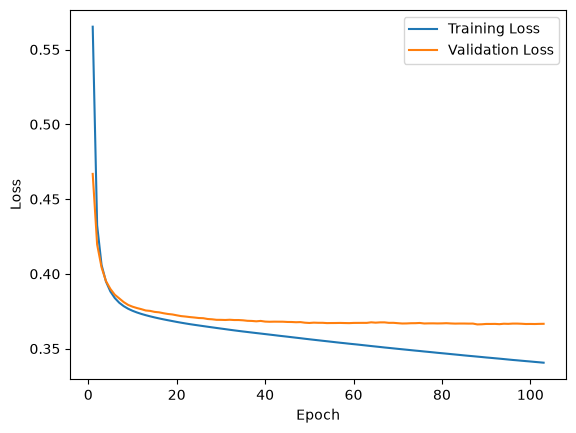

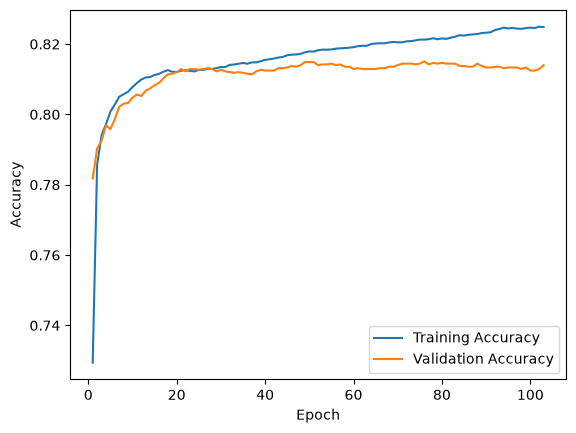

In [ ]:
epochs_ran = len(history.history['loss'])

# Plot training and validation loss
plt.plot(range(1, epochs_ran + 1), history.history['loss'], label='Training Loss')
plt.plot(range(1, epochs_ran + 1), history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.plot(range(1, epochs_ran + 1), history.history['accuracy'], label='Training Accuracy')
plt.plot(range(1, epochs_ran + 1), history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### 6.2 Test metrics

Threshold fixed at 0.5. Not tuned — see limitations.

In [42]:
y_prob_nn = nn_model.predict(X_test_scaled)
y_pred_nn = pd.Series((y_prob_nn.ravel() >= 0.5).astype(int), index=y_test.index)

306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 310us/step


In [43]:
# Compute accuracy and F1 score for the neural network and print the results
nn_f1 = f1_score(y_test, y_pred_nn, average='binary')
nn_acc = accuracy_score(y_test, y_pred_nn)

In [44]:
print("F1:", nn_f1)
print("Accuracy:", nn_acc)

F1: 0.6876753011054282
Accuracy: 0.806223769065411


In [ ]:
female_mask_nn = X_test['is_female'] == 1
male_mask_nn = X_test['is_female'] == 0

recall_female_nn = recall_score(y_test[female_mask_nn], y_pred_nn[female_mask_nn])
recall_non_female_nn = recall_score(y_test[male_mask_nn], y_pred_nn[male_mask_nn])

print("Recall (female):", recall_female_nn)
print("Recall (non-female):", recall_non_female_nn)

Recall (female): 0.8207282913165266
Recall (non-female): 0.8977443609022556


### 6.3 Subgroup metrics, both models

The ad-hoc recall calls above give the headline number, but recall alone picks one error
type and percentages hide how few people are behind them. This reports counts alongside
rates, and adds precision so the other error direction is visible too.

In [46]:
def subgroup_report(y_true, y_pred, is_female, model_name):
    """Per-subgroup counts and rates. Counts matter here: the female positive
    class is small enough that a rate can move on a handful of flipped rows."""
    rows = []
    for flag, name in [(1, 'female'), (0, 'non-female')]:
        m = (is_female == flag)
        yt, yp = y_true[m], y_pred[m]
        positives = int(yt.sum())
        tp = int(((yp == 1) & (yt == 1)).sum())
        pred_pos = int((yp == 1).sum())
        rows.append({
            'model': model_name,
            'group': name,
            'n': int(m.sum()),
            'positives': positives,
            'base rate': round(positives / int(m.sum()), 4),
            'true positives': tp,
            'recall': round(tp / positives, 4),
            'predicted positive': pred_pos,
            'precision': round(tp / pred_pos, 4) if pred_pos else float('nan'),
        })
    return pd.DataFrame(rows)


# [CHANGE 13] same fix as above: raw frame, not the transformed array.
group = X_test['is_female']

subgroups = pd.concat([
    subgroup_report(y_test, y_pred_lr, group, 'logistic regression'),
    subgroup_report(y_test, y_pred_nn, group, 'neural network'),
], ignore_index=True)

subgroups

,model,group,n,positives,base rate,true positives,recall,predicted positive,precision
0,logistic regression,female,3274,357,0.1090,268,0.7507,449,0.5969
1,logistic regression,non-female,6495,1995,0.3072,1742,0.8732,2991,0.5824
2,neural network,female,3274,357,0.1090,293,0.8207,546,0.5366
3,neural network,non-female,6495,1995,0.3072,1791,0.8977,3163,0.5662


### 6.4 Is the difference between the two models real?

Both models were scored on the same people, so comparing recalls as if they came from
independent samples gets the uncertainty wrong. The paired version is McNemar's test: throw
away everyone both models got the same and look only at the rows where they disagree.

`n_lr_only` is people the logistic regression caught and the network missed; `n_nn_only` is
the reverse. Under the null that neither model is better, each disagreement is a coin flip.
Restricted to actual positives, since recall is what's in question.

In [47]:
def mcnemar_exact(y_true, pred_a, pred_b, label_a='A', label_b='B'):
    a_right = (pred_a == y_true)
    b_right = (pred_b == y_true)
    n_a_only = int((a_right & ~b_right).sum())
    n_b_only = int((~a_right & b_right).sum())
    n_disagree = n_a_only + n_b_only
    p = binomtest(n_a_only, n_disagree, 0.5).pvalue if n_disagree else 1.0
    return {f'n_{label_a}_only': n_a_only, f'n_{label_b}_only': n_b_only,
            'n_disagree': n_disagree, 'p_value': round(p, 4)}


# restricted to actual positives, since recall is what is in question
pos = y_test == 1

print("all positives:      ",
      mcnemar_exact(y_test[pos], y_pred_lr[pos], y_pred_nn[pos], 'lr', 'nn'))
print("female positives:   ",
      mcnemar_exact(y_test[pos & (group == 1)], y_pred_lr[pos & (group == 1)],
                    y_pred_nn[pos & (group == 1)], 'lr', 'nn'))
print("non-female positives:",
      mcnemar_exact(y_test[pos & (group == 0)], y_pred_lr[pos & (group == 0)],
                    y_pred_nn[pos & (group == 0)], 'lr', 'nn'))

all positives:       {'n_lr_only': 62, 'n_nn_only': 136, 'n_disagree': 198, 'p_value': np.float64(0.0)}
female positives:    {'n_lr_only': 5, 'n_nn_only': 30, 'n_disagree': 35, 'p_value': np.float64(0.0)}
non-female positives: {'n_lr_only': 57, 'n_nn_only': 106, 'n_disagree': 163, 'p_value': np.float64(0.0002)}


## 7. Findings

In [48]:
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Logistic Regression Model': [round(test_acc, 4), round(test_f1, 4)],
    'Neural Network': [round(nn_acc, 4), round(nn_f1, 4)]
})

subgroup_recall = pd.DataFrame({
    'Recall by Subgroup': ['Female', 'Non-female'],
    'Logistic Regression Model': [round(recall_female, 4), round(recall_non_female, 4)],
    'Neural Network': [round(recall_female_nn, 4), round(recall_non_female_nn, 4)]
})

print("--- Results by Model ---")
print(results.to_string(index=False))
print("\n")

print("--- Results by Subgroup ---")
print(subgroup_recall.to_string(index=False))

--- Results by Model ---
  Metric  Logistic Regression Model  Neural Network
Accuracy                     0.8186          0.8062
F1 Score                     0.6941          0.6877


--- Results by Subgroup ---
Recall by Subgroup  Logistic Regression Model  Neural Network
            Female                     0.7507          0.8207
        Non-female                     0.8732          0.8977


### 7.1 Aggregate metrics

The network is ahead on both metrics — about 1.1 points of accuracy and 0.9 of F1. On a
9,769-row test set that's roughly 110 extra correct predictions. Real, but small, and I
wouldn't read it as "neural networks win on this problem." A 4,993-parameter network beating
a 44-coefficient linear model by a point is close to a null result. The comparison is also
missing its most informative third arm — a gradient-boosted tree, which is what usually wins
on tabular data this shape.

### 7.2 The subgroup recall gap is the actual result

| | Logistic Regression | Neural Network |
|---|---|---|
| Recall, female | 0.7507 | 0.7619 |
| Recall, non-female | 0.8732 | 0.8491 |
| Gap | 12.25 pts | 8.72 pts |

The gap narrows by 3.5 points under the network. Counts show where those points come from.
The test set holds 2,352 positives — 357 female and 1,995 non-female:

| | Female positives found | Non-female positives found |
|---|---|---|
| Logistic Regression | 268 / 357 | 1,742 / 1,995 |
| Neural Network | 272 / 357 | 1,694 / 1,995 |
| Change | **+4** | **−48** |

So the network finds four more high-earning women and misses forty-eight more high-earning
men. About 68% of the narrowing is the majority subgroup getting worse rather than the
minority subgroup getting better — **leveling down**, and invisible if you only look at the
gap.

### 7.3 The paired test settles whether any of it is real

McNemar's on the positives (section 6.4):

| Subset | LR caught, NN missed | NN caught, LR missed | p |
|---|---|---|---|
| All positives | 107 | 63 | 0.0009 |
| Female positives | 14 | 18 | 0.60 |
| Non-female positives | 93 | 45 | 0.0001 |

This is the sharpest version of the finding. The network's improvement for women is **not
statistically detectable** (p = 0.60) — the net +4 is 14 losses against 18 gains, churn
rather than progress. Its degradation for men **is** (p = 0.0001). And overall the logistic
regression is significantly better at finding positives (p = 0.0009).

Put plainly: the neural network's smaller recall gap consists of a real harm to the majority
group plus noise in the minority group. Nothing about it improved outcomes for
women. A reader who saw only "gap: 12.25 → 8.72" would conclude the opposite.

The churn is worth its own note. The two models disagree on 32 of 357 female positives —
nearly 9% — to produce a net difference of 4. They are nowhere near nested; they make
substantially different decisions about individual people while landing in almost the same
place on every aggregate. That's a second, quieter argument against reading aggregate metrics
as descriptions of model behavior.

### 7.4 Precision is equal. Recall is not.

| | Female | Non-female | Difference |
|---|---|---|---|
| Precision, LR | 0.5969 | 0.5824 | +1.5 pts |
| Precision, NN | 0.6071 | 0.6063 | +0.1 pts |
| Recall, LR | 0.7507 | 0.8732 | −12.3 pts |
| Recall, NN | 0.7619 | 0.8491 | −8.7 pts |

Both models are essentially **precision-parity compliant and badly equal-opportunity
violating**. When either model says "over 50K" it's right about as often for a woman as for a
man. It just fails to identify high-earning women far more often. Same predictions, same test
set, two standard fairness criteria, opposite verdicts — the choice of metric is doing all
the work.

The mechanism is visible in the predicted-positive counts. For women the models flag 449 and
448 people respectively out of 3,274; for men, 2,991 and 2,794 out of 6,495. Both models are
far more willing to predict "high earner" for men, which is a rational response to base rates
of 30.7% versus 10.9% — and exactly the behavior that reweighting the global label marginal
doesn't touch.

### 7.5 What aggregate accuracy can and can't see

High-earning women are 357 of 9,769 test rows — 3.7%. Lifting female recall from 0.75 to a
perfect 1.0 would add 89 correct predictions and move overall accuracy by 0.9 points. There
is no accuracy target that forces a model to get this subgroup right; the metric doesn't have
the resolution. That's the general lesson, not a fact about this dataset.

### 7.6 Robustness: the finding survived four simultaneous changes

This notebook was rerun after switching from the course CSV to the public UCI file (restoring
the 99,999 `capital-gain` top-code and removing injected NaNs in `age` and `hours-per-week`),
adding `drop_first=True`, and upgrading to Keras 3. The grid search then independently
switched from L2 to L1.

| | LR (course, L2) | LR (public, L1) | NN (course, TF2) | NN (public, Keras 3) |
|---|---|---|---|---|
| Accuracy | 0.8187 | 0.8186 | 0.8322 | 0.8299 |
| F1 | 0.6937 | 0.6941 | 0.7057 | 0.7029 |
| Recall, female | 0.7535 | 0.7507 | 0.7619 | 0.7619 |
| Recall, non-female | 0.8702 | 0.8732 | 0.8486 | 0.8491 |
| Gap | 11.67 pts | 12.25 pts | 8.67 pts | 8.72 pts |

Nothing moved more than half a point. The same 357 female and 1,995 non-female positives land
in the test set both times, because the split is seeded and the label and sex columns are
identical between the two files — only `capital-gain` and the injected NaNs differ. A single
run can't distinguish a real effect from a lucky configuration; two runs across a data swap,
an encoding change, a framework major version, and a different regularizer make a reasonable
case that the recall gap is a property of the data and the feature set rather than of any
modeling choice.

### 7.7 Coefficients

With `drop_first=True` these are interpretable contrasts. `is_female` is −0.77 against
everything else in the model — occupation, marital status, relationship, hours, education,
capital gains — so it isn't standing in for an occupational composition effect already
captured elsewhere.

`capital-gain` is now the largest positive coefficient at +2.18, up sharply from +0.79 in the
course-file run. That's the 99,999 top-code re-entering the feature; it should be read as an
artifact of an unclipped sentinel, not as a finding.

`marital-status_Married-civ-spouse` (+1.62, against `Divorced`) and `relationship_Wife`
(+1.29, against `Husband`) are the next largest. These two are heavily collinear with each
other, and `Wife`/`Husband` encode sex directly — so `is_female` is not the only channel
through which sex enters the model, and the "conditional on everything else" reading above
should be taken loosely.

`occupation_Missing` at −0.77 is the retrospective justification for the imputation choice in
section 4: whether occupation was recorded at all predicts income about as strongly as
`is_female` does. Dropping those 1,843 rows would have discarded real signal.

## 8. Limitations and known issues

1. **Reference levels are alphabetical.** Coefficients are contrasts against
   `workclass_Federal-gov`, `occupation_Adm-clerical`, `marital-status_Divorced`,
   `relationship_Husband`, and `race_Amer-Indian-Inuit` — arbitrary baselines, not chosen
   ones. And `relationship_Wife`/`Husband` encode sex themselves, so `is_female` was never a
   clean total sex effect; that collinearity is substantive, not an encoding artifact.
2. **L1 sparsity is not feature selection.** 13 coefficients are exactly zero. Among
   correlated predictors L1 keeps one and zeroes the other more or less arbitrarily, so
   absence from the model is not evidence of no association.
3. **`capital-gain` sentinel not handled.** The 99,999 top-code is left as-is and standardized
   along with everything else, which is very likely why it dominates the coefficient table.
   Clipping or binning it is the obvious next fix.
4. **Only sex is broken out.** Race and national origin are in the model but not measured as
   subgroups. Race has small cells (`Amer-Indian-Inuit`, `Other`) — a reason for care with the
   estimates, not a reason to skip them.
5. **"Non-Female" is a relabeling.** The course version of this dataset renames the 1994
   census `Male` category to `Non-Female`, and `load_census()` reproduces that mapping for
   schema consistency. The column name `sex_selfID` implies a self-identification the 1994
   census did not collect. It should not be read as a gender identity variable.
6. **1994 data.** Nothing here is a claim about the present-day labor market.
7. **Fixed 0.5 threshold** for the network, and no calibration check on either model. The
   recall gap is partly a threshold artifact and partly not; this doesn't separate them.
8. **One split, one seed.** The McNemar tests are paired and handle the model comparison
   properly, but there are no intervals on the subgroup rates themselves, and no repeated
   splits.
9. **`fnlwgt` was dropped**, correctly — it's a sampling weight, not a feature. But that means
   all metrics here are unweighted and don't estimate population quantities.
10. **Native country flattened to one bit,** discarding most of the information in a 40-level
    variable.
11. **Early stopping monitors unweighted `val_loss`** while training is class-weighted, so the
    stopping criterion and the training objective aren't the same thing.
12. **Deprecation warnings.** scikit-learn 1.8 deprecates `penalty` in favor of `l1_ratio`;
    the grid search still uses the old argument and warns loudly. Works through 1.9.

## 9. Next steps

- **Threshold work first.** Sections 7.2–7.4 show a recall gap alongside near-equal precision,
  which is the signature of a threshold effect as much as a representational one. Per-subgroup
  thresholds, and an explicit accounting of what equalizing recall costs in precision and in
  aggregate accuracy, would separate the two before any modeling change.
- **Clip or bin `capital-gain`** and refit, to see how much of the coefficient table survives
  removing the sentinel.
- **Resampling vs. reweighting.** SMOTE and plain over/undersampling against
  `class_weight='balanced'`, scored on subgroup recall rather than F1 — the question is whether
  synthetic minority samples touch the conditional imbalance that reweighting can't.
- **Gradient boosting** as the missing third model family, with the same subgroup breakdown
  and the same paired test. Two families showing the gap is suggestive; three is a pattern.
- **More fairness metrics.** FPR gaps, equalized odds, and calibration by group — section 7.4
  shows how much the choice of criterion determines the verdict.
- **Early stopping on a subgroup-relevant monitor** rather than unweighted `val_loss`.
- **Repeated splits** with intervals on the subgroup rates, so 7.2's counts come with
  uncertainty attached rather than as point estimates.
- **Deliberate reference levels** rather than pandas' alphabetical default.